
Dataset Loaded Successfully

Dataset Shape:
(973, 55)

Available Columns:
['Transaction_ID', 'Time', 'Amount', 'Location', 'Transaction_Type', 'Old_Balance', 'Is_International', 'New_Balance', 'Bank_Name', 'Bank_Branch', 'Device_Type', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'KYC_Status', 'Account_Type', 'Customer_Since_Years', 'Avg_Monthly_Balance', 'Account_Number', 'Time_Normalized', 'Amount_Normalized', 'Location_Normalized', 'Transaction_Type_Normalized', 'Old_Balance_Normalized', 'New_Balance_Normalized', 'Bank_Name_Normalized', 'Bank_Branch_Normalized', 'Device_Type_Normalized', 'Customer_Name_Normalized', 'Age_Normalized', 'Gender_Normalized', 'City_Normalized', 'KYC_Status_Normalized', 'Account_Type_Normalized', 'Customer_Since_Years_Normalized', 'Avg_Monthly_Balance_Normalized', 'Time_Standardized', 'Amount_Standardized', 'Location_Standardized', 'Transaction_Type_Standardized', 'Old_Balance_Standardized', 'New_Balance_Standardized', 'Bank_Name_Standardized'

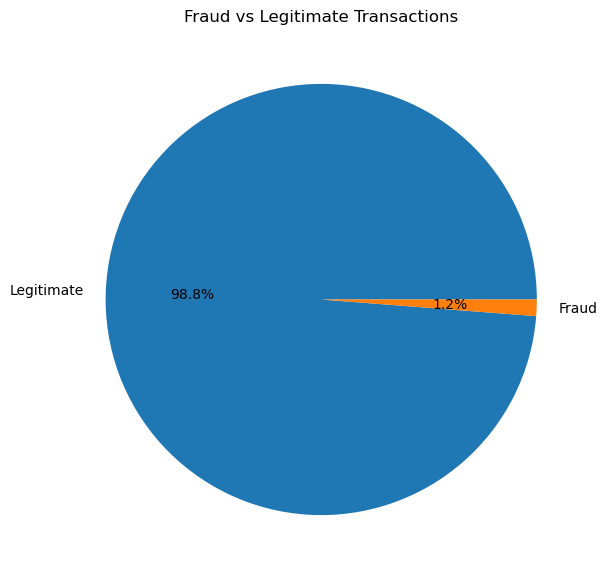

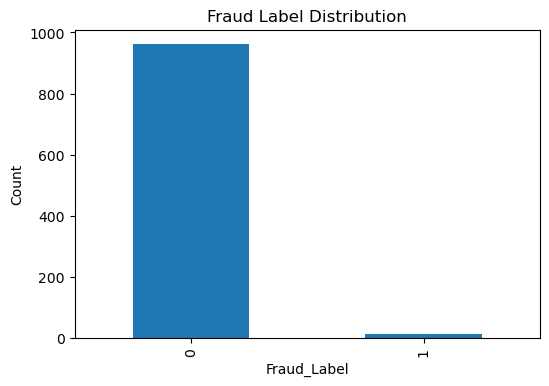


Sample Fraud Transactions:
     Transaction_ID  Time     Amount  Location  Transaction_Type  Old_Balance  \
81    TXNW0AHGXIJIX   883   43060.35         1                 0     93966.65   
103  IMPSHGBERO4NYO   729  238408.95         2                 2     77479.11   
214  NEFTZ989N8KTYX   345   49062.76         1                 0     87437.78   
302   UPI5HQWZDH6W1   937   47576.35         2                 2     85445.22   
313  NEFTGBNT6GNLB3   977   43356.34         0                 0     55230.68   

     Is_International  New_Balance  Bank_Name  Bank_Branch  ...  \
81                  1     50906.30          0            1  ...   
103                 1     61585.18          5            4  ...   
214                 1     38375.02          1            4  ...   
302                 1     37868.87          3            2  ...   
313                 1     11874.34          3            4  ...   

     Device_Type_Standardized Customer_Name_Standardized  Age_Standardized  \
81  

In [2]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# CREATE FRAUD_LABEL COLUMN
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 2. LOAD DATASET
# ============================================================

# CHANGE FILE PATH IF REQUIRED

df = pd.read_csv(
    r"Corrected_Cleaned_Normalized_Standardized_Dataset.csv"
)

print("\nDataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 3. DISPLAY COLUMNS
# ============================================================

print("\nAvailable Columns:")
print(df.columns.tolist())


# ============================================================
# 4. CHECK IMPORTANT COLUMNS
# ============================================================

required_cols = [
    'Transaction_Amount',
    'Is_International'
]

for col in required_cols:

    if col not in df.columns:

        print(f"\nWARNING: {col} column not found")


# ============================================================
# 5. CREATE FRAUD LABEL COLUMN
# ============================================================

# Fraud Rule:
#
# Fraud_Label = 1
# IF:
# 1. Transaction amount is high
# AND
# 2. Transaction is international
#
# Else:
# Fraud_Label = 0


df['Fraud_Label'] = np.where(

    (
        (df['Amount'] > 40000)
        &
        (df['Is_International'] == 1)
    ),

    1,

    0
)


# ============================================================
# 6. DISPLAY FRAUD DISTRIBUTION
# ============================================================

print("\nFraud Label Distribution:")

print(df['Fraud_Label'].value_counts())


# ============================================================
# 7. PIE CHART
# ============================================================

plt.figure(figsize=(7,7))

df['Fraud_Label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=[
        'Legitimate',
        'Fraud'
    ]
)

plt.title("Fraud vs Legitimate Transactions")

plt.ylabel("")

plt.show()


# ============================================================
# 8. BAR GRAPH
# ============================================================

plt.figure(figsize=(6,4))

df['Fraud_Label'].value_counts().plot.bar()

plt.title("Fraud Label Distribution")

plt.xlabel("Fraud_Label")

plt.ylabel("Count")

plt.show()


# ============================================================
# 9. DISPLAY SAMPLE FRAUD RECORDS
# ============================================================

fraud_rows = df[
    df['Fraud_Label'] == 1
]

print("\nSample Fraud Transactions:")

print(fraud_rows.head())


# ============================================================
# 10. SAVE UPDATED DATASET
# ============================================================

df.to_csv(
    "Dataset_With_Fraud_Label.csv",
    index=False
)

print("\n====================================")

print("DATASET WITH FRAUD LABEL CREATED")

print("====================================")

print("\nGenerated File:")

print("Dataset_With_Fraud_Label.csv")


# ============================================================
# 11. FINAL DATASET PREVIEW
# ============================================================

print("\nFinal Dataset Preview:")

print(df.head())



Dataset Loaded Successfully

Dataset Shape:
(973, 56)

Available Columns:
['Transaction_ID', 'Time', 'Amount', 'Location', 'Transaction_Type', 'Old_Balance', 'Is_International', 'New_Balance', 'Bank_Name', 'Bank_Branch', 'Device_Type', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'KYC_Status', 'Account_Type', 'Customer_Since_Years', 'Avg_Monthly_Balance', 'Account_Number', 'Time_Normalized', 'Amount_Normalized', 'Location_Normalized', 'Transaction_Type_Normalized', 'Old_Balance_Normalized', 'New_Balance_Normalized', 'Bank_Name_Normalized', 'Bank_Branch_Normalized', 'Device_Type_Normalized', 'Customer_Name_Normalized', 'Age_Normalized', 'Gender_Normalized', 'City_Normalized', 'KYC_Status_Normalized', 'Account_Type_Normalized', 'Customer_Since_Years_Normalized', 'Avg_Monthly_Balance_Normalized', 'Time_Standardized', 'Amount_Standardized', 'Location_Standardized', 'Transaction_Type_Standardized', 'Old_Balance_Standardized', 'New_Balance_Standardized', 'Bank_Name_Standardized'

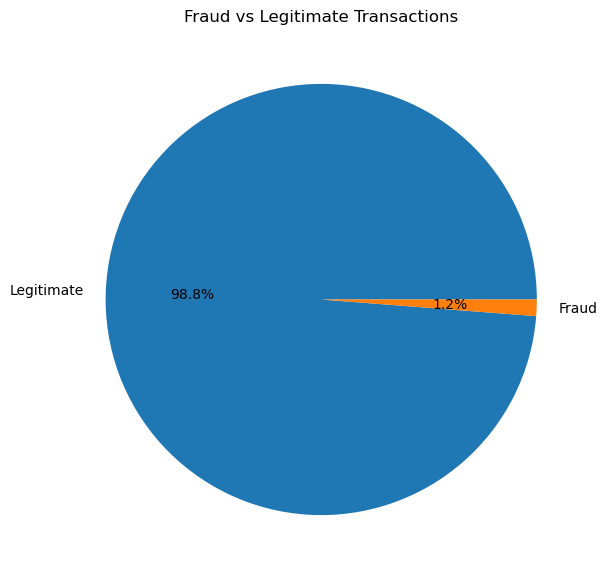

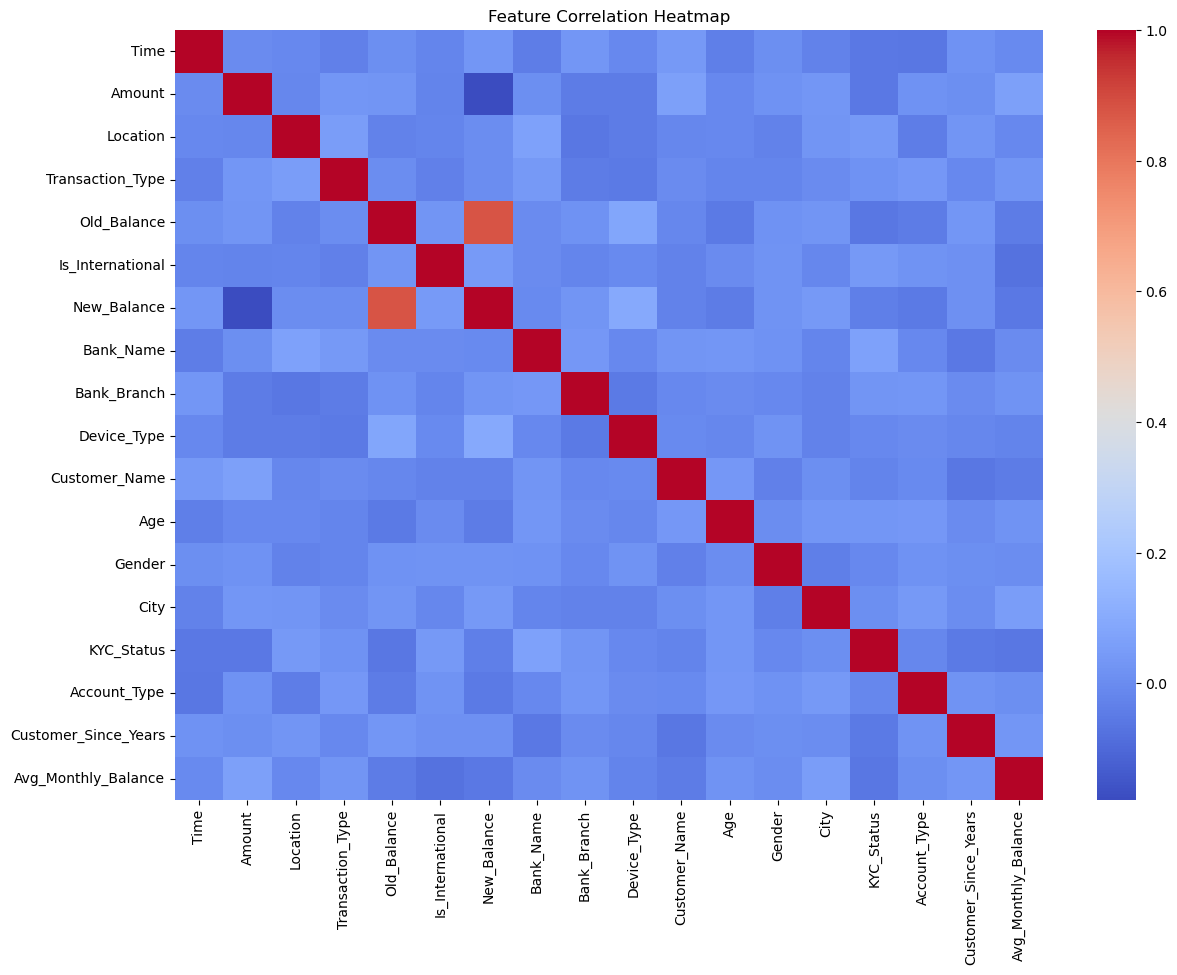


Highly Correlated Columns:
[]

Shape After Removing Correlated Features:
(973, 18)

Feature Correlation With Fraud_Label
Fraud_Label             1.000000
Is_International        0.358874
Amount                  0.172929
Old_Balance             0.066788
Customer_Since_Years    0.055049
Account_Type            0.054119
Bank_Branch             0.052363
City                    0.022738
Customer_Name           0.022471
Gender                  0.012702
New_Balance             0.008218
Time                    0.008184
Transaction_Type        0.002715
Avg_Monthly_Balance     0.000425
Device_Type            -0.011411
KYC_Status             -0.011550
Bank_Name              -0.017394
Location               -0.044565
Age                    -0.055034
Name: Fraud_Label, dtype: float64

Chi-Square Feature Scores:
                 Feature     Chi2_Score
1                 Amount  579598.461193
4            Old_Balance   66252.577109
6            New_Balance    1485.094271
5       Is_International     

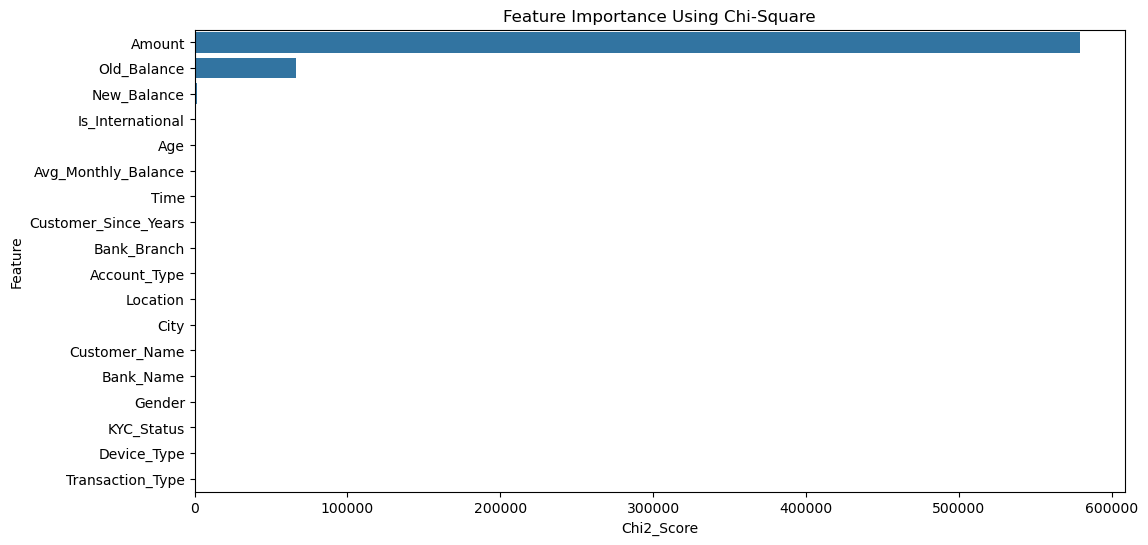


Train-Test Split Completed

X_train Shape: (778, 18)
X_test Shape: (195, 18)

Normalization Completed

Standardization Completed


<Figure size 1000x500 with 0 Axes>

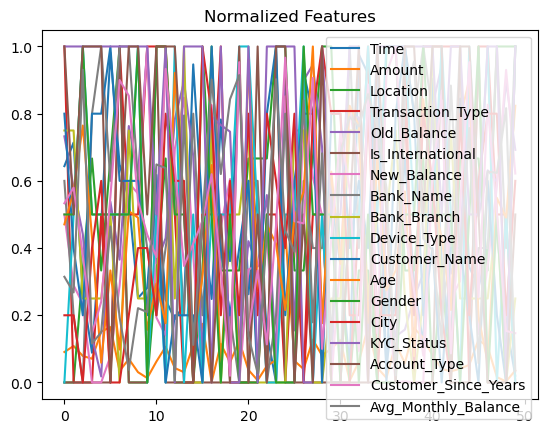

<Figure size 1000x500 with 0 Axes>

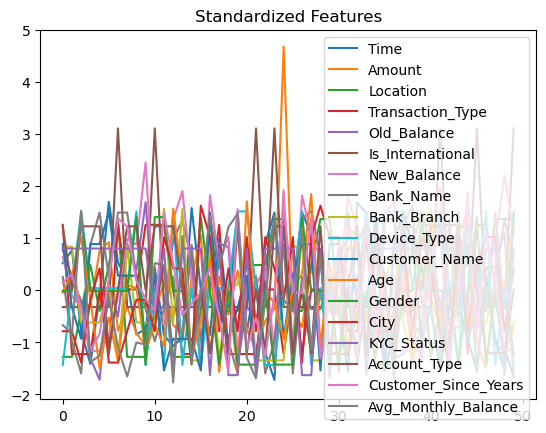


FEATURE SELECTION COMPLETED
MODEL READY DATASETS GENERATED

Generated Files:
1. Feature_Selected_Dataset.csv
2. KNN_X_Train_Normalized.csv
3. KNN_X_Test_Normalized.csv
4. LR_SVM_X_Train_Standardized.csv
5. LR_SVM_X_Test_Standardized.csv
6. Y_Train.csv
7. Y_Test.csv

IMPORTANT:
Use class_weight='balanced'
for Logistic Regression and SVM
because fraud datasets are imbalanced.


In [5]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# FEATURE SELECTION + MODEL READY PREPROCESSING
# (UPDATED VERSION WITH FRAUD_LABEL DATASET)
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2
)


# ============================================================
# 2. LOAD DATASET
# ============================================================

# LOAD DATASET CREATED AFTER ADDING Fraud_Label

df = pd.read_csv(
    "Dataset_With_Fraud_Label.csv"
)

print("\nDataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 3. DISPLAY DATASET COLUMNS
# ============================================================
print("\nAvailable Columns:")
print(df.columns.tolist())


# ============================================================
# 4. REMOVE PREVIOUS NORMALIZED/STANDARDIZED COLUMNS
# ============================================================

remove_cols = [

    col for col in df.columns

    if "_Normalized" in col
    or "_Standardized" in col
]

df = df.drop(columns=remove_cols)

print("\nRemoved Old Normalized/Standardized Columns")

print("Updated Shape:", df.shape)


# ============================================================
# 5. REMOVE ID COLUMNS
# ============================================================

# IDs are not useful for ML prediction

id_cols = [
    'Transaction_ID',
    'Customer_ID',
    'Account_Number'
]

existing_id_cols = [

    col for col in id_cols

    if col in df.columns
]

df = df.drop(columns=existing_id_cols)

print("\nID Columns Removed")

print("Updated Shape:", df.shape)


# ============================================================
# 6. CHECK TARGET COLUMN
# ============================================================

TARGET_COLUMN = 'Fraud_Label'

if TARGET_COLUMN not in df.columns:

    raise ValueError(
        "\nFraud_Label column not found in dataset"
    )

print("\nTarget Column Found:")
print(TARGET_COLUMN)


# ============================================================
# 7. SEPARATE FEATURES & TARGET
# ============================================================

X = df.drop(columns=[TARGET_COLUMN])

y = df[TARGET_COLUMN]

print("\nFeature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)


# ============================================================
# 8. CHECK CLASS IMBALANCE
# ============================================================

print("\nFraud Class Distribution:")

print(y.value_counts())


# ============================================================
# 9. PIE CHART FOR FRAUD DISTRIBUTION
# ============================================================

plt.figure(figsize=(7,7))

y.value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Legitimate', 'Fraud']
)

plt.title("Fraud vs Legitimate Transactions")

plt.ylabel("")

plt.show()


# ============================================================
# 10. FEATURE CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    X.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()


# ============================================================
# 11. REMOVE HIGHLY CORRELATED FEATURES
# ============================================================

correlation_matrix = X.corr().abs()

upper_triangle = correlation_matrix.where(

    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_cols = [

    column

    for column in upper_triangle.columns

    if any(upper_triangle[column] > 0.90)
]

print("\nHighly Correlated Columns:")

print(high_corr_cols)


# Remove correlated features
X = X.drop(columns=high_corr_cols)

print("\nShape After Removing Correlated Features:")

print(X.shape)


# ============================================================
# 12. FEATURE IMPORTANCE USING CORRELATION
# ============================================================

feature_corr = pd.concat([X, y], axis=1).corr()

fraud_corr = feature_corr[TARGET_COLUMN].sort_values(
    ascending=False
)

print("\nFeature Correlation With Fraud_Label")

print(fraud_corr)


# ============================================================
# 13. FEATURE SELECTION USING CHI-SQUARE
# ============================================================

# Chi-square requires non-negative values

X_positive = X.copy()

for col in X_positive.columns:

    min_val = X_positive[col].min()

    if min_val < 0:

        X_positive[col] = (
            X_positive[col] - min_val
        )

selector = SelectKBest(
    score_func=chi2,
    k='all'
)

selector.fit(X_positive, y)

feature_scores = pd.DataFrame({

    'Feature': X.columns,

    'Chi2_Score': selector.scores_
})

feature_scores = feature_scores.sort_values(
    by='Chi2_Score',
    ascending=False
)

print("\nChi-Square Feature Scores:")

print(feature_scores)


# ============================================================
# 14. BAR GRAPH FOR FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Chi2_Score',
    y='Feature',
    data=feature_scores
)

plt.title("Feature Importance Using Chi-Square")

plt.show()


# ============================================================
# 15. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("\nTrain-Test Split Completed")

print("\nX_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)


# ============================================================
# 16. NORMALIZATION FOR KNN
# ============================================================

minmax_scaler = MinMaxScaler()

X_train_normalized = minmax_scaler.fit_transform(
    X_train
)

X_test_normalized = minmax_scaler.transform(
    X_test
)

print("\nNormalization Completed")


# ============================================================
# 17. STANDARDIZATION FOR LR & SVM
# ============================================================

std_scaler = StandardScaler()

X_train_standardized = std_scaler.fit_transform(
    X_train
)

X_test_standardized = std_scaler.transform(
    X_test
)

print("\nStandardization Completed")


# ============================================================
# 18. CONVERT TO DATAFRAMES
# ============================================================

X_train_normalized_df = pd.DataFrame(

    X_train_normalized,

    columns=X.columns
)

X_test_normalized_df = pd.DataFrame(

    X_test_normalized,

    columns=X.columns
)

X_train_standardized_df = pd.DataFrame(

    X_train_standardized,

    columns=X.columns
)

X_test_standardized_df = pd.DataFrame(

    X_test_standardized,

    columns=X.columns
)


# ============================================================
# 19. VISUALIZE NORMALIZED DATA
# ============================================================

plt.figure(figsize=(10,5))

X_train_normalized_df.head(50).plot()

plt.title("Normalized Features")

plt.show()


# ============================================================
# 20. VISUALIZE STANDARDIZED DATA
# ============================================================

plt.figure(figsize=(10,5))

X_train_standardized_df.head(50).plot()

plt.title("Standardized Features")

plt.show()


# ============================================================
# 21. SAVE FEATURE SELECTED DATASET
# ============================================================

selected_dataset = pd.concat(
    [X, y],
    axis=1
)

selected_dataset.to_csv(
    "Feature_Selected_Dataset.csv",
    index=False
)


# ============================================================
# 22. SAVE MODEL READY FILES
# ============================================================

X_train_normalized_df.to_csv(
    "KNN_X_Train_Normalized.csv",
    index=False
)

X_test_normalized_df.to_csv(
    "KNN_X_Test_Normalized.csv",
    index=False
)

X_train_standardized_df.to_csv(
    "LR_SVM_X_Train_Standardized.csv",
    index=False
)

X_test_standardized_df.to_csv(
    "LR_SVM_X_Test_Standardized.csv",
    index=False
)

y_train.to_csv(
    "Y_Train.csv",
    index=False
)

y_test.to_csv(
    "Y_Test.csv",
    index=False
)


# ============================================================
# 23. FINAL OUTPUT
# ============================================================

print("\n====================================")

print("FEATURE SELECTION COMPLETED")

print("MODEL READY DATASETS GENERATED")

print("====================================")


print("\nGenerated Files:")

print("1. Feature_Selected_Dataset.csv")

print("2. KNN_X_Train_Normalized.csv")

print("3. KNN_X_Test_Normalized.csv")

print("4. LR_SVM_X_Train_Standardized.csv")

print("5. LR_SVM_X_Test_Standardized.csv")

print("6. Y_Train.csv")

print("7. Y_Test.csv")


# ============================================================
# 24. IMPORTANT NOTE
# ============================================================

print("\nIMPORTANT:")

print("Use class_weight='balanced'")
print("for Logistic Regression and SVM")
print("because fraud datasets are imbalanced.")